<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/Sprint_Prosthesis_Biomechanics_Pilot_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint Prosthesis Biomechanics Pilot Study

This notebook analyzes sprint acceleration biomechanics in a unilateral transtibial amputee using a running-specific prosthesis compared with an able-bodied control. The workflow processes markerless kinematics, ground reaction force, and EMG data to evaluate asymmetrical loading strategies, neuromuscular compensation, and athlete adaptation during stance.

## Tools Used
- Python
- pandas / NumPy
- Matplotlib / Seaborn
- SciPy
- spm1d
- Theia3D markerless kinematics
- AMTI force plates
- Delsys EMG
- Visual3D-derived exports

## Research Focus
The goal of this pilot analysis was to identify how a running-specific prosthesis changes sprint stance mechanics compared with able-bodied sprinting. The analysis focused on vertical ground reaction force, lower-limb joint kinematics, and EMG activation patterns across time-normalized stance phases.

In [9]:
import urllib.request
import zipfile
import os

# --------------------------------------------------
# STUDENT INPUT (edit only this line; case-sensitive)
# --------------------------------------------------
GROUP = "lannister"   # e.g., "targaryen", "stark", "lannister"

# --------------------------------------------------
# Configuration (do NOT edit below)
# These lines create a directory for this lab in your
# Colab working directory.
# --------------------------------------------------
zip_dir = "kin6016/pilot"
os.makedirs(zip_dir, exist_ok=True)

zip_filename = f"spring2026_pilot_{GROUP}.zip"

url = (
    "https://raw.githubusercontent.com/"
    "plnu-biomechanics/kin6016/main/"
    f"labs/{zip_filename}"
)

zip_path = os.path.join(zip_dir, zip_filename)

# --------------------------------------------------
# Download zip file
# --------------------------------------------------
urllib.request.urlretrieve(url, zip_path)

# --------------------------------------------------
# Extract contents from the zipped file
# --------------------------------------------------
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(zip_dir)

print("Extracted files in lab directory:")
print(os.listdir(zip_dir))



Extracted files in lab directory:
['Lannister_Pilot_Amputee_05.txt', 'Lannister_Pilot_Amputee_04.txt', 'Lannister_Pilot_Amputee_03.txt', 'Lannister_Pilot_Amputee_02.txt', 'Lannister_Pilot_Able_04.txt', 'Lannister_Pilot_Able_05.txt', 'Lannister_Pilot_Able_01.txt', 'spring2026_pilot_lannister.zip', 'Lannister_Pilot_Able_02.txt', 'Lannister_Pilot_Able_03.txt', 'Lannister_Pilot_Amputee_01.txt']


## Statistical Parametric Mapping Analysis

Because sprint stance is a continuous movement rather than a single isolated value, this notebook uses 1D Statistical Parametric Mapping to compare time-series curves across the full stance phase. This helps identify where meaningful differences occur during ground contact instead of only comparing peak values.

In [10]:
import glob
import pandas as pd
import numpy as np
import os

# =============================================================================
# DEFINE VARIABLES & COMPILE DATAFRAMES
# =============================================================================
data_dir = "kin6016/pilot"
GROUPS = ["amputee", "able_bodied"]

txt_files = glob.glob(os.path.join(data_dir, "**", "*.txt"), recursive=True)

# UPDATED: Added 'Left GRF' to the time-series list (Now 7 variables)
timeseries_vars = [
    'Left GRF', 'Right GRF', 'L_GASTROC', 'L_HAMSTRING',
    'L_QUADRICEP', 'R_HAMSTRING', 'R_QUADRICEP'
]

discrete_vars = [
    'L_PLANTAR_FLEXION', 'L_DORSI_FLEXION', 'Left_Max_Hip_Flexion',
    'Left_Max_Hip_Extension', 'Left_Max_Knee_Flexion', 'Right_Max_Hip_Flexion',
    'Right_Max_Hip_Extension', 'Right_Max_Knee_Flexion'
]

ts_list = []
discrete_list = []

for file in txt_files:
    file_lower = file.lower()
    if "amputee" in file_lower:
        group = "amputee"
    elif "able" in file_lower:
        group = "able_bodied"
    else:
        continue

    # Skip the Vicon/Nexus metadata rows
    df_raw = pd.read_csv(file, sep='\t', skiprows=[0, 2, 3, 4], header=0)

    # 1. Extract Time-Series (101 frames representing the normalized stance phase)
    df_ts = df_raw[timeseries_vars].head(101).copy()
    df_ts['Group'] = group
    df_ts['Filename'] = os.path.basename(file)
    df_ts['Frame'] = range(1, 102)
    ts_list.append(df_ts)

    # 2. Extract Discretes (Row 0 only)
    df_disc = df_raw[discrete_vars].iloc[[0]].copy()
    df_disc['Group'] = group
    df_disc['Filename'] = os.path.basename(file)
    discrete_list.append(df_disc)

timeseries_df = pd.concat(ts_list, ignore_index=True)
discrete_df = pd.concat(discrete_list, ignore_index=True)

# =============================================================================
# WRANGLE THE DATA FOR SPM (j trials x 101 frames arrays)
# =============================================================================
spm_data = {}

for group in GROUPS:
    spm_data[group] = {}
    df_group = timeseries_df[timeseries_df['Group'] == group]
    trials = df_group['Filename'].unique()

    for var in timeseries_vars:
        trial_arrays = []
        for trial in trials:
            df_trial = df_group[df_group['Filename'] == trial].sort_values('Frame')
            trial_arrays.append(df_trial[var].values)

        if trial_arrays:
            spm_data[group][var] = np.vstack(trial_arrays)

print(f"Successfully parsed {len(txt_files)} files with independent Left/Right stance normalization.")

Successfully parsed 10 files with independent Left/Right stance normalization.


## Key Findings

The amputee demonstrated a stiffer intact-limb strategy during sprint acceleration, with reduced hip and knee flexion compared with the able-bodied control. The intact limb also showed higher mid-stance vertical ground reaction force and greater EMG activation, suggesting increased stabilization and propulsion demands.

The prosthetic limb showed delayed force production during late stance, consistent with the spring-like behavior of the running-specific prosthesis. EMG patterns also suggested greater proximal muscle contribution to stabilize and load the prosthetic side.

Overall, the analysis showed that the intact limb acted more like the primary stabilizing and propulsive limb, while the prosthetic limb relied more on delayed elastic energy return.

--- Independent T-Tests: Discrete Joint Kinematics ---
L_PLANTAR_FLEXION         | t:   1.85 | p: 0.102 
L_DORSI_FLEXION           | t:  -1.90 | p: 0.094 
Left_Max_Hip_Flexion      | t:  -6.75 | p: 0.000 *
Left_Max_Hip_Extension    | t:   0.98 | p: 0.355 
Left_Max_Knee_Flexion     | t:  -2.69 | p: 0.027 *
Right_Max_Hip_Flexion     | t:   0.22 | p: 0.831 
Right_Max_Hip_Extension   | t:   0.40 | p: 0.701 
Right_Max_Knee_Flexion    | t:   4.50 | p: 0.002 *


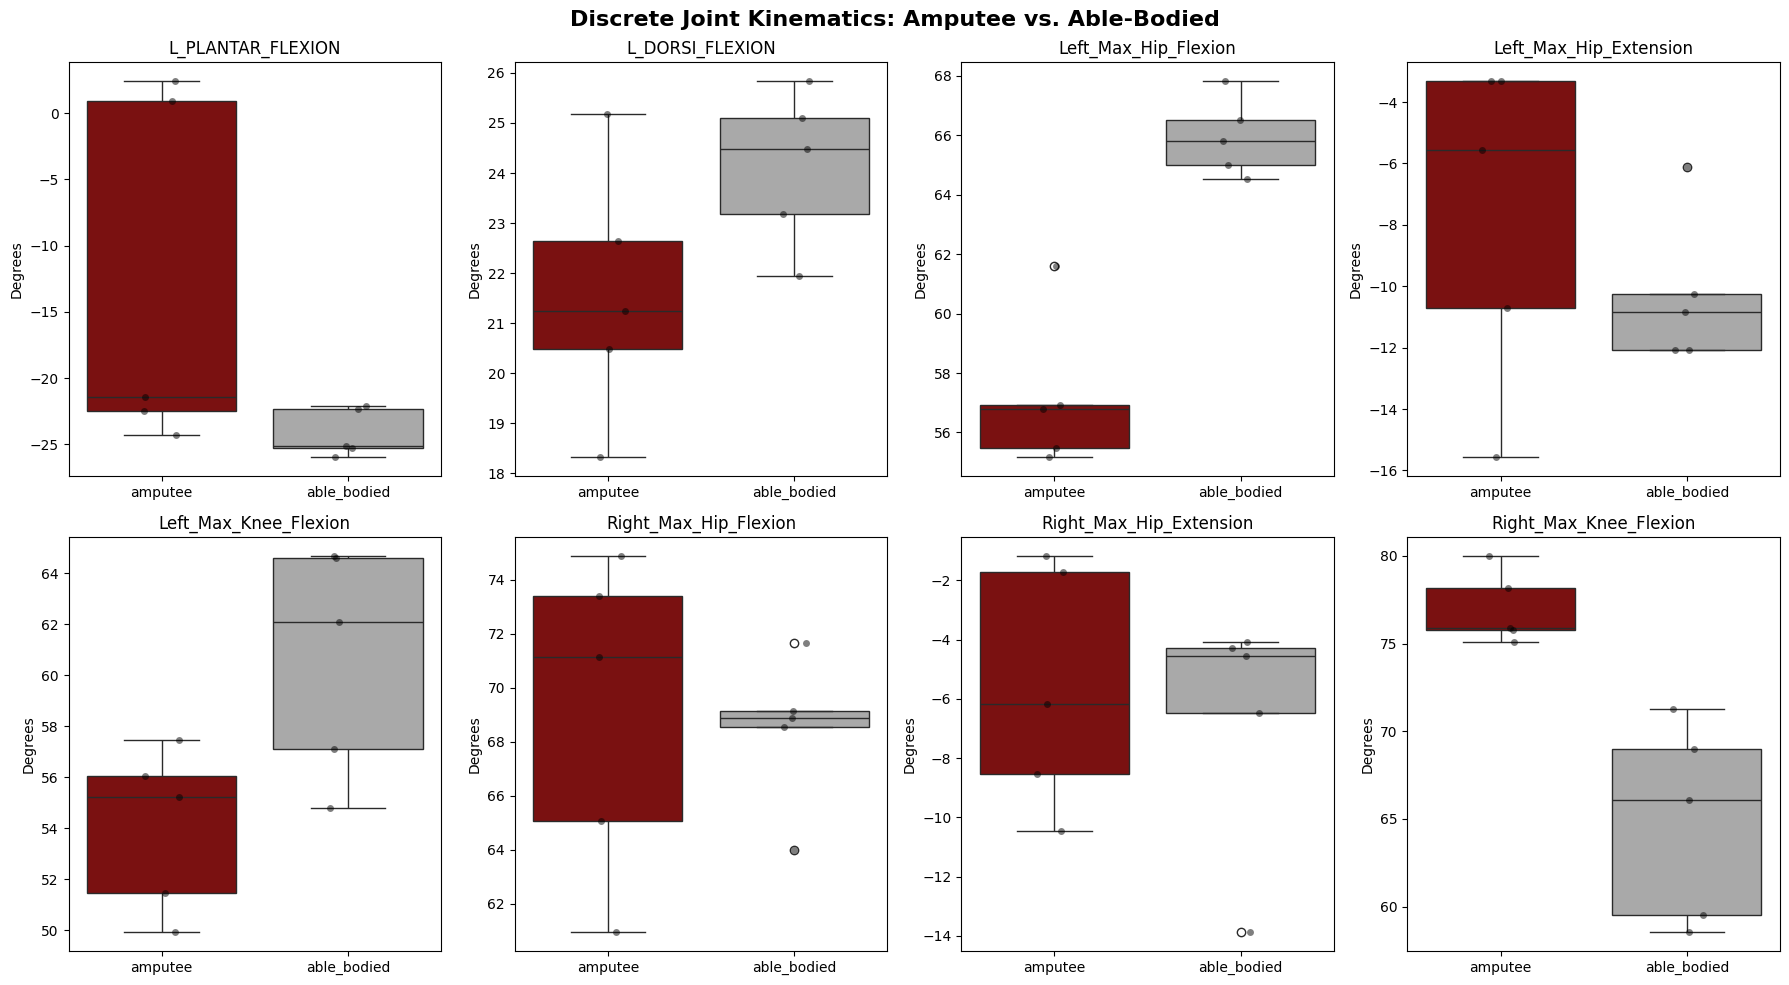

In [11]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Independent T-Tests: Discrete Joint Kinematics ---")
results = []

for var in discrete_vars:
    # Isolate groups
    amputee_data = discrete_df[discrete_df['Group'] == 'amputee'][var].dropna()
    able_data = discrete_df[discrete_df['Group'] == 'able_bodied'][var].dropna()

    # Run independent t-test
    t_stat, p_val = stats.ttest_ind(amputee_data, able_data, equal_var=True)

    # Flag significance
    sig = "*" if p_val < 0.05 else ""
    print(f"{var:<25} | t: {t_stat:>6.2f} | p: {p_val:>5.3f} {sig}")

# Generate Boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Discrete Joint Kinematics: Amputee vs. Able-Bodied', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, var in enumerate(discrete_vars):
    sns.boxplot(
        x='Group',
        y=var,
        hue='Group',
        data=discrete_df,
        ax=axes[i],
        palette={'amputee':'darkred', 'able_bodied':'darkgrey'},
        legend=False
    )
    sns.stripplot(x='Group', y=var, data=discrete_df, ax=axes[i], color='black', alpha=0.5, jitter=True)

    axes[i].set_title(var, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Degrees')

plt.tight_layout()
plt.show()

In [12]:
!pip install spm1d
print("spm1d library installed.")

spm1d library installed.


Generating 4x2 SPM Plots...


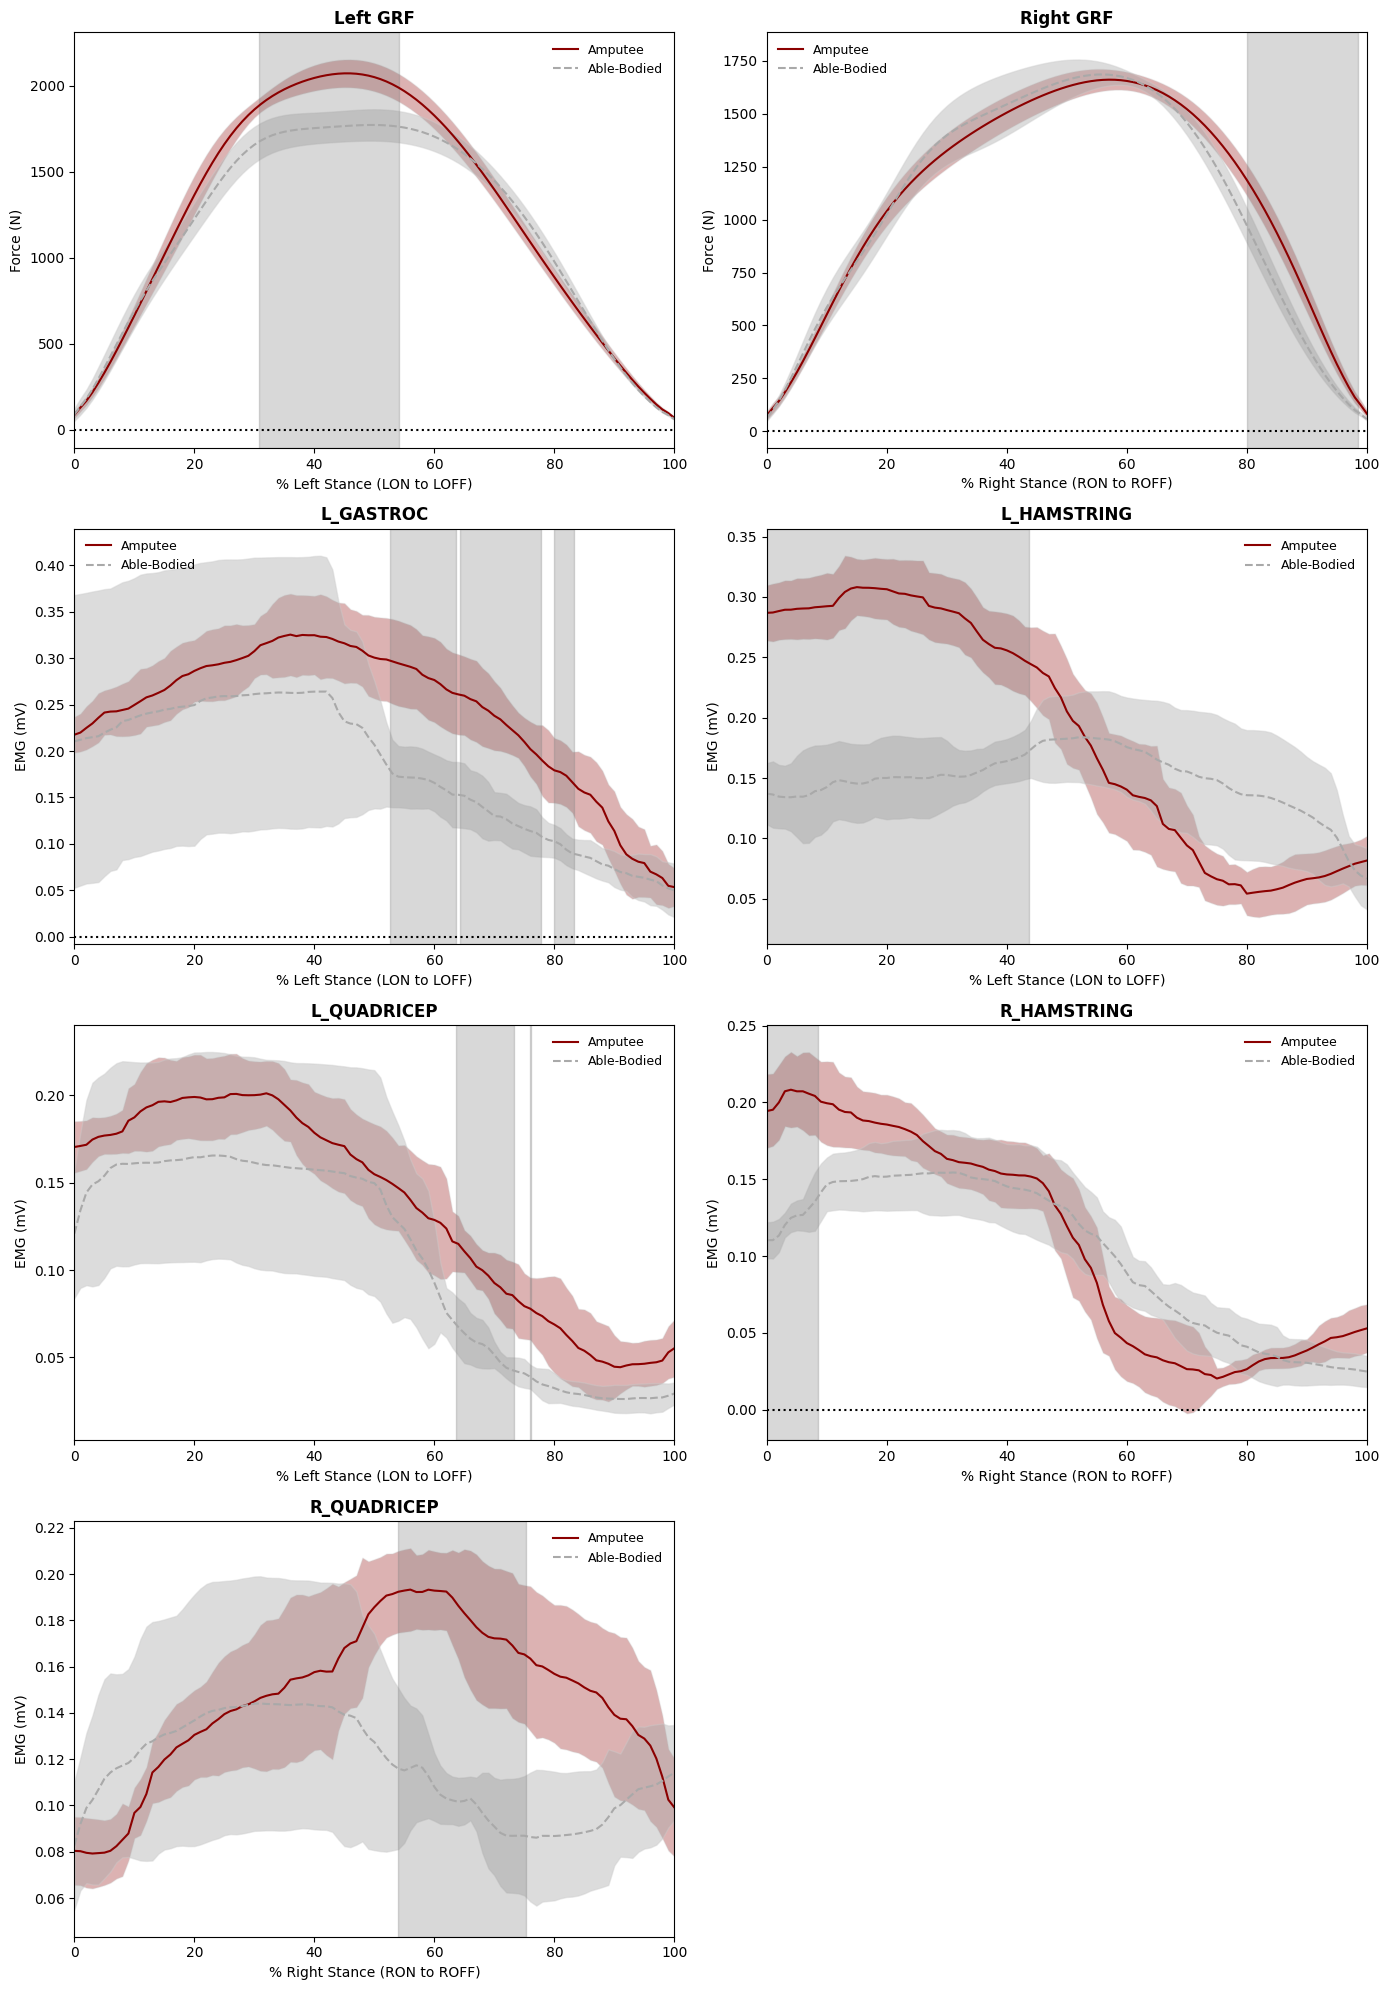

In [13]:
import spm1d
import matplotlib.pyplot as plt
import numpy as np

total_frames = 101

def plot_spm(ax, Y1, Y2, label_Y1, label_Y2, title, y_label, x_label):
    spm1d.plot.plot_mean_sd(Y1, label=label_Y1, linecolor='darkred', facecolor='darkred', ax=ax, lw=1.5, alpha=0.3)
    spm1d.plot.plot_mean_sd(Y2, label=label_Y2, linecolor='darkgrey', facecolor='darkgrey', linestyle='--', lw=1.5, alpha=0.4, ax=ax)
    ax.axhline(y=0, color='k', linestyle=':')

    Y1_copy, Y2_copy = Y1.copy(), Y2.copy()
    for j in range(Y1_copy.shape[1]):
        if np.var(Y1_copy[:, j]) == 0: Y1_copy[:, j] += np.random.rand(Y1_copy.shape[0]) * 1e-9
        if np.var(Y2_copy[:, j]) == 0: Y2_copy[:, j] += np.random.rand(Y2_copy.shape[0]) * 1e-9

    alpha = 0.05
    t = spm1d.stats.ttest2(Y1_copy, Y2_copy)
    ti = t.inference(alpha, two_tailed=True, interp=True)

    for cluster in ti.clusters:
        start, end = cluster.endpoints
        ax.axvspan(start, end, ymin=0, ymax=1.0, color='grey', alpha=0.30)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 100)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.legend(fontsize=9, loc='best', frameon=False)

print("Generating 4x2 SPM Plots...")
# UPDATED: 4x2 grid to fit 7 variables
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

y_labels = {
    'Left GRF': 'Force (N)',
    'Right GRF': 'Force (N)',
    'L_GASTROC': 'EMG (mV)',
    'L_HAMSTRING': 'EMG (mV)',
    'L_QUADRICEP': 'EMG (mV)',
    'R_HAMSTRING': 'EMG (mV)',
    'R_QUADRICEP': 'EMG (mV)'
}

for i, var in enumerate(timeseries_vars):
    YA = spm_data['amputee'][var]
    YB = spm_data['able_bodied'][var]

    # UPDATED: Dynamically assign the correct X-axis label based on the variable
    if var.startswith('L'):
        x_label = '% Left Stance (LON to LOFF)'
    else:
        x_label = '% Right Stance (RON to ROFF)'

    plot_spm(axes[i], YA, YB, "Amputee", "Able-Bodied", var, y_labels[var], x_label)

# Hide the 8th empty subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

Continuous Time-Series Data (Statistical Parametric Mapping)
Independent samples t-tests conducted via 1D Statistical Parametric Mapping (SPM1D) revealed significant kinetic and electromyographic (EMG) differences between the amputee and able-bodied participant across their respective normalized stance phases.

Left Stance Phase (Intact Limb)
Analysis of the intact limb (Left On to Left Off) demonstrated significant increases in both force production and neuromuscular activation in the amputee compared to the able-bodied baseline:

Kinetics: Left Ground Reaction Force (GRF) exhibited a significant supra-threshold cluster during mid-stance (approximately 30%–55% of the stance phase), indicating higher vertical force absorption and generation.

Muscular Activation (EMG): The L_HAMSTRING showed significantly higher activation during early stance (0%–40%), representing elevated stabilization demands upon initial contact. Furthermore, both L_GASTROC and L_QUADRICEP exhibited massive significant clusters throughout the latter half of the stance phase (50%–100%), highlighting increased active propulsion.

Right Stance Phase (Prosthetic Limb)
Analysis of the prosthetic limb (Right On to Right Off) revealed a highly altered kinetic and neuromuscular profile:

Kinetics: Right GRF analysis yielded a significant cluster during the final 20% of the stance phase (80%–100%). The amputee's peak vertical force was significantly delayed compared to the able-bodied participant, corresponding to the late-stance elastic recoil of the carbon fiber prosthesis.

Muscular Activation (EMG): Proximal musculature showed distinct compensatory firing patterns. The R_HAMSTRING exhibited a brief but significant cluster at initial contact (0%–10%), while the R_QUADRICEP demonstrated significantly higher activation during mid-stance (approximately 55%–75%).

Discrete Joint Kinematics
Independent samples t-tests were conducted to compare maximal joint excursions between the amputee and the able-bodied participant. The analysis revealed significant kinematic asymmetries, particularly regarding the flexion strategies of the knee and hip.

Intact Limb (Left):
The amputee exhibited a significantly stiffer kinematic profile on the intact side. Both maximum hip and knee flexion were significantly reduced compared to the able-bodied participant:

Left Max Hip Flexion: Significantly lower in the amputee (t = -6.75, p < 0.001).

Left Max Knee Flexion: Significantly lower in the amputee (t = -2.69, p = 0.027).

Left Max Hip Extension (p = 0.355), Left Plantar Flexion (p = 0.102), and Left Dorsiflexion (p = 0.094) did not reach statistical significance.

Prosthetic Limb (Right):
Conversely, the prosthetic limb demonstrated a significantly more compliant strategy at the knee, while hip kinematics remained largely consistent with the baseline:

Right Max Knee Flexion: Significantly higher in the amputee (t = 4.50, p = 0.002).

Right Max Hip Flexion (p = 0.831) and Right Max Hip Extension (p = 0.701) showed no significant differences between the two conditions.